# Correct Data Summary

Notebook này tổng hợp kết quả trong `results/correct_data` cho data policy mới:

- giữ full dialogue timeline;
- utterance ngoài 4 class là `context` / `ignore_index=-100`;
- loss và metrics chỉ tính trên 4 emotion target classes.

Notebook tự scan các file `cross_session_summary.json` và `metrics.json`, nên khi có run mới chỉ cần chạy lại notebook.

In [45]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

ROOT_CANDIDATES = [Path('results/correct_data'), Path('.')]
ROOT = next((candidate for candidate in ROOT_CANDIDATES if (candidate / 'main').exists() or (candidate / 'cim_cdm_ablation').exists()), Path('results/correct_data'))
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ['WA', 'UA', 'WF1', 'Macro-F1']
sns.set_theme(style='whitegrid', font_scale=1.0)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 200)


In [46]:
def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding='utf-8'))


def pct(value: Any) -> float:
    if value is None:
        return np.nan
    value = float(value)
    return value * 100.0 if abs(value) <= 1.5 else value


def infer_suite(path: Path) -> str:
    rel = path.relative_to(ROOT)
    parts = rel.parts
    if not parts:
        return 'unknown'
    if parts[0] == 'main':
        return 'main'
    if parts[0] == 'cim_cdm_ablation':
        return 'cim_cdm_ablation'
    if parts[0] == 'features':
        return f"features/{parts[1]}" if len(parts) > 1 else 'features'
    return parts[0]


def infer_ssl_arch_variant(path: Path) -> tuple[str, str, str]:
    rel = path.relative_to(ROOT)
    parts = rel.parts
    suite = infer_suite(path)
    if suite == 'main' and len(parts) >= 3:
        return parts[1], parts[2], 'full'
    if suite == 'cim_cdm_ablation' and len(parts) >= 3:
        return parts[1], 'cdm_cim', parts[2]
    if suite.startswith('features/') and len(parts) >= 4:
        return parts[2], parts[3], parts[1]
    return 'unknown', 'unknown', 'unknown'


def run_id_from_path(path: Path) -> str:
    parts = path.parts
    if 'cross_session' in parts:
        idx = parts.index('cross_session')
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return path.parent.name


def load_cross_session_rows(root: Path = ROOT) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    fold_rows = []
    for path in sorted(root.glob('**/cross_session_summary.json')):
        payload = read_json(path)
        suite = infer_suite(path)
        ssl, arch, variant = infer_ssl_arch_variant(path)
        run_id = run_id_from_path(path)
        aggregate = payload.get('aggregate', {})
        row = {
            'suite': suite,
            'ssl': ssl,
            'arch': arch,
            'variant': variant,
            'run_id': run_id,
            'summary_path': str(path),
            'output_dir': str(path.parent),
        }
        for metric in METRICS:
            stats = aggregate.get(metric, {})
            row[f'{metric}_mean'] = pct(stats.get('mean'))
            row[f'{metric}_std'] = pct(stats.get('std'))
            row[f'{metric}_n'] = stats.get('n', len(payload.get('folds', [])))
        summary_rows.append(row)

        for fold in payload.get('folds', []):
            metrics = fold.get('metrics', {})
            fold_row = {
                'suite': suite,
                'ssl': ssl,
                'arch': arch,
                'variant': variant,
                'run_id': run_id,
                'test_session': int(fold.get('test_session', -1)),
                'output_dir': fold.get('output_dir', ''),
            }
            for metric in METRICS:
                fold_row[metric] = pct(metrics.get(metric))
            fold_rows.append(fold_row)
    return pd.DataFrame(summary_rows), pd.DataFrame(fold_rows)


def load_single_metric_rows(root: Path = ROOT) -> pd.DataFrame:
    rows = []
    for path in sorted(root.glob('**/metrics.json')):
        # Cross-session folds are already represented above but keeping them here is useful for audits.
        payload = read_json(path)
        metrics = payload.get('test', payload)
        suite = infer_suite(path)
        ssl, arch, variant = infer_ssl_arch_variant(path)
        row = {
            'suite': suite,
            'ssl': ssl,
            'arch': arch,
            'variant': variant,
            'path': str(path),
            'output_dir': str(path.parent),
            'epoch': metrics.get('epoch'),
            'loss': metrics.get('loss'),
        }
        session_match = re.search(r'test_Ses(\d+)', str(path))
        row['test_session'] = int(session_match.group(1)) if session_match else np.nan
        for metric in METRICS:
            row[metric] = pct(metrics.get(metric))
        rows.append(row)
    return pd.DataFrame(rows)


def metric_text(mean: float, std: float | None = None, n: int | None = None) -> str:
    if pd.isna(mean):
        return ''
    if std is None or pd.isna(std) or (n is not None and n <= 1):
        return f'{mean:.2f}'
    return f'{mean:.2f} ± {std:.2f}'


def style_metric_table(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    table = df.copy()
    for metric in METRICS:
        mean_col, std_col, n_col = f'{metric}_mean', f'{metric}_std', f'{metric}_n'
        if mean_col in table:
            table[metric] = [metric_text(m, s, n) for m, s, n in zip(table[mean_col], table.get(std_col, np.nan), table.get(n_col, np.nan))]
    keep = ['suite', 'ssl', 'arch', 'variant', 'run_id', *METRICS, 'output_dir']
    keep = [col for col in keep if col in table.columns]
    return table[keep]



In [47]:
summary_df, folds_df = load_cross_session_rows(ROOT)
single_df = load_single_metric_rows(ROOT)
print(f'cross-session summaries: {len(summary_df)}')
print(f'fold rows: {len(folds_df)}')
print(f'metrics files: {len(single_df)}')


cross-session summaries: 11
fold rows: 53
metrics files: 76


## Cross-Session Overview

In [48]:
if summary_df.empty:
    display(pd.DataFrame({'message': ['No cross_session_summary.json found yet.']}))
else:
    display(
        style_metric_table(
            summary_df.sort_values(['suite', 'ssl', 'arch', 'variant'])
        )
    )


,suite,ssl,arch,variant,run_id,WA,UA,WF1,Macro-F1,output_dir
0,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,run_20260706_135045,67.20 ± 0.36,68.86 ± 1.99,66.83 ± 0.48,68.18 ± 1.05,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045
1,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,62.63 ± 1.88,63.47 ± 2.50,62.17 ± 2.13,62.75 ± 2.27,cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355
2,cim_cdm_ablation,wavlm,cdm_cim,zero_interaction_memory,run_20260706_113306,68.27 ± 4.62,69.19 ± 3.72,67.34 ± 5.12,68.05 ± 4.69,cim_cdm_ablation/wavlm/zero_interaction_memory/cross_session/run_20260706_113306
3,features/4new,wavlm,baseline,4new,run_20260706_120026,55.42 ± 3.42,56.44 ± 3.04,54.09 ± 4.25,54.39 ± 4.25,features/4new/wavlm/baseline/cross_session/run_20260706_120026
4,features/4new,wavlm,cdm,4new,run_20260706_120717,67.54 ± 3.05,68.98 ± 3.50,66.81 ± 2.97,67.86 ± 2.86,features/4new/wavlm/cdm/cross_session/run_20260706_120717
5,features/4new,wavlm,cdm_cim,4new,run_20260706_093400,68.10 ± 5.88,68.89 ± 5.22,67.32 ± 6.40,67.93 ± 5.78,features/4new/wavlm/cdm_cim/cross_session/run_20260706_093400
6,features/4new,wavlm,cim,4new,run_20260706_093905,69.08 ± 4.57,70.26 ± 4.99,68.07 ± 5.35,69.07 ± 5.08,features/4new/wavlm/cim/cross_session/run_20260706_093905
7,main,wavlm,baseline,full,run_20260706_114003,55.42 ± 3.42,56.44 ± 3.04,54.09 ± 4.25,54.39 ± 4.25,main/wavlm/baseline/cross_session/run_20260706_114003
8,main,wavlm,cdm,full,run_20260706_114632,67.54 ± 3.05,68.98 ± 3.50,66.81 ± 2.97,67.86 ± 2.86,main/wavlm/cdm/cross_session/run_20260706_114632
9,main,wavlm,cdm_cim,full,run_20260706_091202,67.80 ± 5.47,69.02 ± 5.22,66.89 ± 6.03,67.81 ± 5.56,main/wavlm/cdm_cim/cross_session/run_20260706_091202


## Main Results

In [49]:
main_df = summary_df[summary_df['suite'].eq('main')].copy() if not summary_df.empty else pd.DataFrame()
if main_df.empty:
    display(pd.DataFrame({'message': ['No main cross-session results found yet.']}))
else:
    display(style_metric_table(main_df.sort_values('Macro-F1_mean', ascending=False)))


,suite,ssl,arch,variant,run_id,WA,UA,WF1,Macro-F1,output_dir
10,main,wavlm,cim,full,run_20260706_132857,68.53 ± 3.33,69.28 ± 4.69,67.78 ± 3.60,68.48 ± 3.82,main/wavlm/cim/cross_session/run_20260706_132857
8,main,wavlm,cdm,full,run_20260706_114632,67.54 ± 3.05,68.98 ± 3.50,66.81 ± 2.97,67.86 ± 2.86,main/wavlm/cdm/cross_session/run_20260706_114632
9,main,wavlm,cdm_cim,full,run_20260706_091202,67.80 ± 5.47,69.02 ± 5.22,66.89 ± 6.03,67.81 ± 5.56,main/wavlm/cdm_cim/cross_session/run_20260706_091202
7,main,wavlm,baseline,full,run_20260706_114003,55.42 ± 3.42,56.44 ± 3.04,54.09 ± 4.25,54.39 ± 4.25,main/wavlm/baseline/cross_session/run_20260706_114003


## Main Heatmap

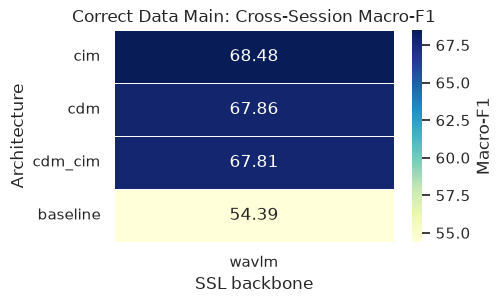

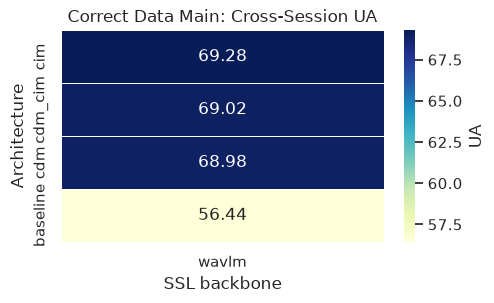

In [50]:
def plot_heatmap(df: pd.DataFrame, value_col: str, title: str, path: Path):
    if df.empty or value_col not in df:
        print(f'Skip {title}: no data')
        return
    pivot = df.pivot_table(index='arch', columns='ssl', values=value_col, aggfunc='mean')
    if pivot.empty:
        print(f'Skip {title}: empty pivot')
        return
    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]
    plt.figure(figsize=(max(5, 1.4 * len(pivot.columns)), max(3, 0.55 * len(pivot.index) + 1)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': value_col.replace('_mean', '')})
    plt.title(title)
    plt.xlabel('SSL backbone')
    plt.ylabel('Architecture')
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()

plot_heatmap(main_df, 'Macro-F1_mean', 'Correct Data Main: Cross-Session Macro-F1', FIG_DIR / 'main_macro_f1_heatmap.png')
plot_heatmap(main_df, 'UA_mean', 'Correct Data Main: Cross-Session UA', FIG_DIR / 'main_ua_heatmap.png')


## Fold-Level Results

In [51]:
if folds_df.empty:
    display(pd.DataFrame({'message': ['No fold-level rows found yet.']}))
else:
    cols = ['suite', 'ssl', 'arch', 'variant', 'run_id', 'test_session', *METRICS, 'output_dir']
    display(folds_df[cols].sort_values(['suite', 'ssl', 'arch', 'variant', 'test_session']))


,suite,ssl,arch,variant,run_id,test_session,WA,UA,WF1,Macro-F1,output_dir
0,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,run_20260706_135045,1,66.820276,71.158626,66.378743,67.995046,results/correct_data/cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses01
1,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,run_20260706_135045,2,67.546432,67.786294,67.333384,69.307857,results/correct_data/cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses02
2,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,run_20260706_135045,3,67.245873,67.640272,66.769186,67.226510,results/correct_data/cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses03
3,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,1,65.529954,67.171902,65.537840,66.458584,results/correct_data/cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses01
4,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,2,63.049853,64.026182,62.850043,63.395411,results/correct_data/cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses02
5,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,3,61.077324,61.493113,61.048225,61.476249,results/correct_data/cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses03
6,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,4,62.657614,60.829576,61.346884,61.006249,results/correct_data/cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses04
7,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,5,60.838034,63.811873,60.071783,61.398930,results/correct_data/cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses05
8,cim_cdm_ablation,wavlm,cdm_cim,zero_interaction_memory,run_20260706_113306,1,61.566820,65.739136,60.017785,61.417240,results/correct_data/cim_cdm_ablation/wavlm/zero_interaction_memory/cross_session/run_20260706_113306/test_Ses01
9,cim_cdm_ablation,wavlm,cdm_cim,zero_interaction_memory,run_20260706_113306,2,67.155425,66.151336,65.885016,66.911512,results/correct_data/cim_cdm_ablation/wavlm/zero_interaction_memory/cross_session/run_20260706_113306/test_Ses02


## Fold Heatmap

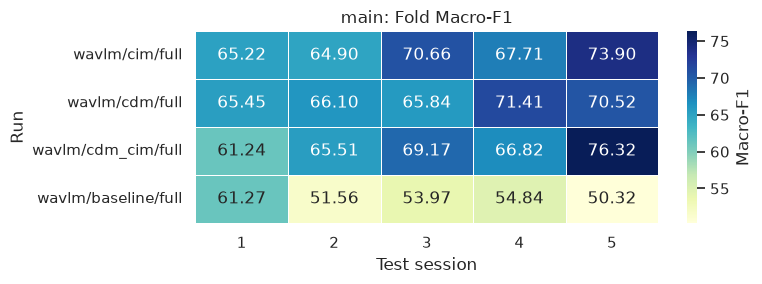

In [52]:
def plot_fold_heatmap(df: pd.DataFrame, suite: str, metric: str, path: Path):
    subset = df[df['suite'].eq(suite)].copy() if not df.empty else pd.DataFrame()
    if subset.empty:
        print(f'Skip {suite}: no folds')
        return
    subset['run_label'] = subset['ssl'] + '/' + subset['arch'] + '/' + subset['variant']
    pivot = subset.pivot_table(index='run_label', columns='test_session', values=metric, aggfunc='mean')
    if pivot.empty:
        print(f'Skip {suite}: empty pivot')
        return
    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]
    plt.figure(figsize=(8, max(3, 0.45 * len(pivot.index) + 1)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': metric})
    plt.title(f'{suite}: Fold {metric}')
    plt.xlabel('Test session')
    plt.ylabel('Run')
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()

plot_fold_heatmap(folds_df, 'main', 'Macro-F1', FIG_DIR / 'main_fold_macro_f1_heatmap.png')


## CDM+CIM Memory Ablation

In [53]:
ablation_df = summary_df[summary_df['suite'].eq('cim_cdm_ablation')].copy() if not summary_df.empty else pd.DataFrame()
if ablation_df.empty:
    display(pd.DataFrame({'message': ['No cim_cdm_ablation cross-session results found yet.']}))
else:
    display(style_metric_table(ablation_df.sort_values(['ssl', 'Macro-F1_mean'], ascending=[True, False])))


,suite,ssl,arch,variant,run_id,WA,UA,WF1,Macro-F1,output_dir
0,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,run_20260706_135045,67.20 ± 0.36,68.86 ± 1.99,66.83 ± 0.48,68.18 ± 1.05,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045
2,cim_cdm_ablation,wavlm,cdm_cim,zero_interaction_memory,run_20260706_113306,68.27 ± 4.62,69.19 ± 3.72,67.34 ± 5.12,68.05 ± 4.69,cim_cdm_ablation/wavlm/zero_interaction_memory/cross_session/run_20260706_113306
1,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,run_20260706_091355,62.63 ± 1.88,63.47 ± 2.50,62.17 ± 2.13,62.75 ± 2.27,cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355


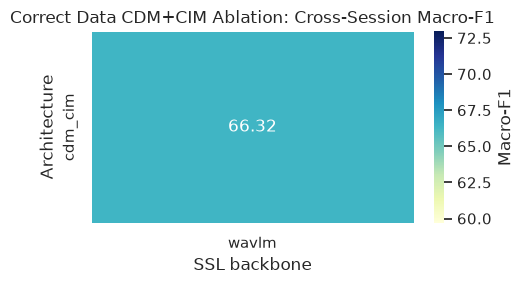

In [54]:
plot_heatmap(ablation_df, 'Macro-F1_mean', 'Correct Data CDM+CIM Ablation: Cross-Session Macro-F1', FIG_DIR / 'cim_cdm_ablation_macro_f1_heatmap.png')


## Feature Set Experiments

In [55]:
features_df = summary_df[summary_df['suite'].str.startswith('features/', na=False)].copy() if not summary_df.empty else pd.DataFrame()
if features_df.empty:
    display(pd.DataFrame({'message': ['No feature-set cross-session results found yet.']}))
else:
    display(style_metric_table(features_df.sort_values(['suite', 'ssl', 'arch', 'Macro-F1_mean'], ascending=[True, True, True, False])))


,suite,ssl,arch,variant,run_id,WA,UA,WF1,Macro-F1,output_dir
3,features/4new,wavlm,baseline,4new,run_20260706_120026,55.42 ± 3.42,56.44 ± 3.04,54.09 ± 4.25,54.39 ± 4.25,features/4new/wavlm/baseline/cross_session/run_20260706_120026
4,features/4new,wavlm,cdm,4new,run_20260706_120717,67.54 ± 3.05,68.98 ± 3.50,66.81 ± 2.97,67.86 ± 2.86,features/4new/wavlm/cdm/cross_session/run_20260706_120717
5,features/4new,wavlm,cdm_cim,4new,run_20260706_093400,68.10 ± 5.88,68.89 ± 5.22,67.32 ± 6.40,67.93 ± 5.78,features/4new/wavlm/cdm_cim/cross_session/run_20260706_093400
6,features/4new,wavlm,cim,4new,run_20260706_093905,69.08 ± 4.57,70.26 ± 4.99,68.07 ± 5.35,69.07 ± 5.08,features/4new/wavlm/cim/cross_session/run_20260706_093905


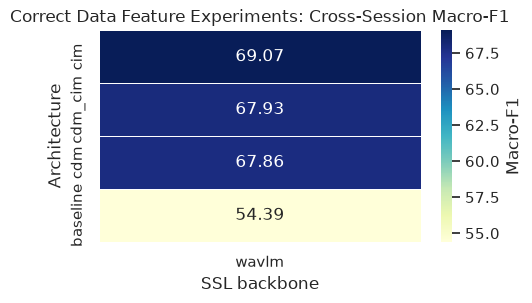

In [56]:
if not features_df.empty:
    plot_heatmap(features_df, 'Macro-F1_mean', 'Correct Data Feature Experiments: Cross-Session Macro-F1', FIG_DIR / 'features_macro_f1_heatmap.png')


## Single Metrics Files Audit

In [57]:
if single_df.empty:
    display(pd.DataFrame({'message': ['No metrics.json files found yet.']}))
else:
    cols = ['suite', 'ssl', 'arch', 'variant', 'test_session', 'epoch', 'loss', *METRICS, 'path']
    cols = [col for col in cols if col in single_df.columns]
    display(single_df[cols].sort_values(['suite', 'ssl', 'arch', 'variant', 'test_session'], na_position='last'))


,suite,ssl,arch,variant,test_session,epoch,loss,WA,UA,WF1,Macro-F1,path
0,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,1,82,1.025394,66.820276,71.158626,66.378743,67.995046,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses01/metrics.json
1,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,1,82,1.025394,66.820276,71.158626,66.378743,67.995046,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses01/phase_tests/end_to_end/...
2,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,2,62,0.915112,67.546432,67.786294,67.333384,69.307857,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses02/metrics.json
3,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,2,62,0.915112,67.546432,67.786294,67.333384,69.307857,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses02/phase_tests/end_to_end/...
4,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,3,58,0.923054,67.245873,67.640272,66.769186,67.226510,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses03/metrics.json
5,cim_cdm_ablation,wavlm,cdm_cim,shuffled_dialogue_memory,3,58,0.923054,67.245873,67.640272,66.769186,67.226510,cim_cdm_ablation/wavlm/shuffled_dialogue_memory/cross_session/run_20260706_135045/test_Ses03/phase_tests/end_to_end/...
6,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,1,134,0.930622,65.529954,67.171902,65.537840,66.458584,cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses01/metrics.json
7,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,1,134,0.930622,65.529954,67.171902,65.537840,66.458584,cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses01/phase_tests/end_to_end/metr...
8,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,2,105,0.961095,63.049853,64.026182,62.850043,63.395411,cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses02/metrics.json
9,cim_cdm_ablation,wavlm,cdm_cim,zero_dialogue_memory,2,105,0.961095,63.049853,64.026182,62.850043,63.395411,cim_cdm_ablation/wavlm/zero_dialogue_memory/cross_session/run_20260706_091355/test_Ses02/phase_tests/end_to_end/metr...


## Publication-Style Tables

Bảng dạng paper với cột `Backbone`, `Model`, `WA`, `UA`, `WF1`, `Macro-F1`. Best được **bold**, second-best được <u>underline</u> theo từng backbone và từng metric. Notebook export tất cả bảng có dữ liệu vào chung `results/correct_data/tables/`: `main`, `features/4new`, và `cim_cdm_ablation`.


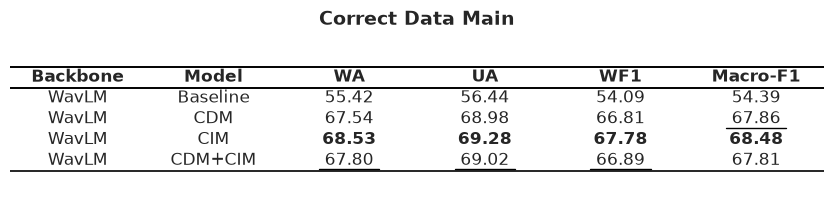

,Backbone,Model,WA,UA,WF1,Macro-F1
0,WavLM,Baseline,55.42,56.44,54.09,54.39
1,WavLM,CDM,67.54,68.98,66.81,67.86
2,WavLM,CIM,68.53,69.28,67.78,68.48
3,WavLM,CDM+CIM,67.80,69.02,66.89,67.81


tables/main_publication_table.csv
tables/main_publication_table.tex
tables/main_publication_table.png


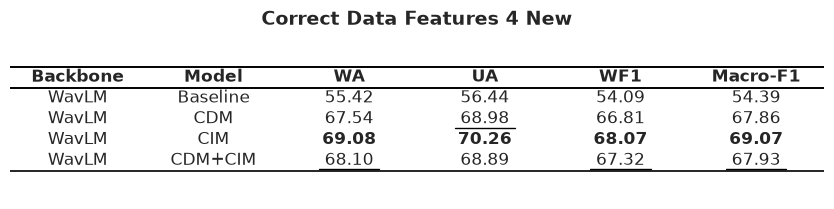

,Backbone,Model,WA,UA,WF1,Macro-F1
0,WavLM,Baseline,55.42,56.44,54.09,54.39
1,WavLM,CDM,67.54,68.98,66.81,67.86
2,WavLM,CIM,69.08,70.26,68.07,69.07
3,WavLM,CDM+CIM,68.10,68.89,67.32,67.93


tables/features_4new_publication_table.csv
tables/features_4new_publication_table.tex
tables/features_4new_publication_table.png


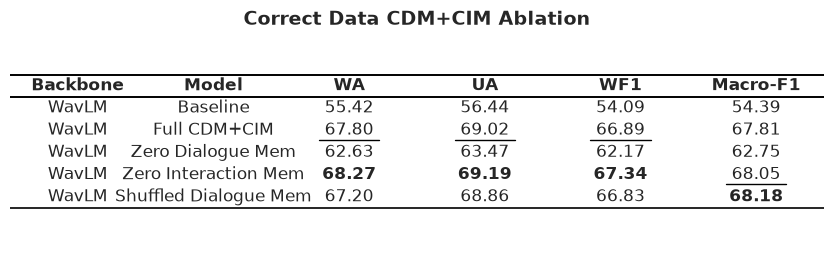

,Backbone,Model,WA,UA,WF1,Macro-F1
0,WavLM,Baseline,55.42,56.44,54.09,54.39
1,WavLM,Full CDM+CIM,67.80,69.02,66.89,67.81
2,WavLM,Zero Dialogue Mem,62.63,63.47,62.17,62.75
3,WavLM,Zero Interaction Mem,68.27,69.19,67.34,68.05
4,WavLM,Shuffled Dialogue Mem,67.20,68.86,66.83,68.18


tables/cim_cdm_ablation_publication_table.csv
tables/cim_cdm_ablation_publication_table.tex
tables/cim_cdm_ablation_publication_table.png


In [58]:
TABLE_DIR = ROOT / 'tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE_LABELS = {
    'wavlm': 'WavLM',
    'hubert': 'HuBERT',
    'wav2vec': 'Wav2Vec2',
}
MODEL_LABELS = {
    'baseline': 'Baseline',
    'cdm': 'CDM',
    'cim': 'CIM',
    'cdm_cim': 'CDM+CIM',
    'cdm_cim_fusion_head': 'CDM+CIM Fusion Head',
    'cdm_cim_logit_fusion': 'CDM+CIM Logit Fusion',
}
ABLATION_LABELS = {
    'baseline': 'Baseline',
    'full': 'Full CDM+CIM',
    'zero_dialogue_memory': 'Zero Dialogue Mem',
    'zero_interaction_memory': 'Zero Interaction Mem',
    'zero_both_memory': 'Zero Both Mem',
    'shuffled_dialogue_memory': 'Shuffled Dialogue Mem',
    'shuffled_interaction_memory': 'Shuffled Interaction Mem',
}
MODEL_ORDER = ['baseline', 'cdm', 'cim', 'cdm_cim', 'cdm_cim_fusion_head', 'cdm_cim_logit_fusion']
ABLATION_ORDER = [
    'baseline',
    'full',
    'zero_dialogue_memory',
    'zero_interaction_memory',
    'zero_both_memory',
    'shuffled_dialogue_memory',
    'shuffled_interaction_memory',
]


def _order_index(value: str, order: list[str]) -> int:
    return order.index(value) if value in order else 99


def _summary_rows(summary: pd.DataFrame, suite: str) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    df = summary[summary['suite'].eq(suite)].copy()
    if df.empty:
        return pd.DataFrame()
    rows = []
    for _, row in df.iterrows():
        rows.append({
            'suite': row['suite'],
            'ssl': row['ssl'],
            'arch': row['arch'],
            'variant': row['variant'],
            'source': 'cross_session_summary',
            'n_folds': row.get('WA_n', np.nan),
            **{metric: row.get(f'{metric}_mean', np.nan) for metric in METRICS},
        })
    return pd.DataFrame(rows)


def _single_metric_fallback_rows(summary: pd.DataFrame, single: pd.DataFrame, suite: str) -> pd.DataFrame:
    if single.empty:
        return pd.DataFrame()
    existing = set()
    if not summary.empty:
        summary_suite = summary[summary['suite'].eq(suite)]
        existing = set(zip(summary_suite['ssl'], summary_suite['arch'], summary_suite['variant']))

    df = single[single['suite'].eq(suite)].copy()
    if df.empty:
        return pd.DataFrame()
    # Keep direct fold-level test metrics only; avoid duplicated phase_tests/end_to_end metrics.
    df = df[df['path'].astype(str).str.contains(r'test_Ses\d+/metrics\.json$', regex=True)]
    if df.empty:
        return pd.DataFrame()
    df = df[~df.apply(lambda r: (r['ssl'], r['arch'], r['variant']) in existing, axis=1)]
    if df.empty:
        return pd.DataFrame()

    rows = []
    for (ssl, arch, variant), group in df.groupby(['ssl', 'arch', 'variant'], sort=False):
        rows.append({
            'suite': suite,
            'ssl': ssl,
            'arch': arch,
            'variant': variant,
            'source': 'metrics_fallback',
            'n_folds': int(group['test_session'].nunique()),
            **{metric: group[metric].mean() for metric in METRICS},
        })
    return pd.DataFrame(rows)


def build_publication_table(
    summary: pd.DataFrame,
    suite: str,
    row_source: str = 'arch',
    include_single_fallback: bool = False,
) -> pd.DataFrame:
    rows_df = _summary_rows(summary, suite)
    if include_single_fallback:
        fallback = _single_metric_fallback_rows(summary, single_df, suite)
        rows_df = pd.concat([rows_df, fallback], ignore_index=True) if not fallback.empty else rows_df
    if rows_df.empty:
        return pd.DataFrame(columns=['Backbone', 'Model', *METRICS])

    rows_df['Backbone'] = rows_df['ssl'].map(BACKBONE_LABELS).fillna(rows_df['ssl'])
    if row_source == 'variant':
        rows_df['Model'] = rows_df['variant'].map(ABLATION_LABELS).fillna(rows_df['variant'])
        rows_df['model_order'] = rows_df['variant'].apply(lambda x: _order_index(x, ABLATION_ORDER))
    else:
        rows_df['Model'] = rows_df['arch'].map(MODEL_LABELS).fillna(rows_df['arch'])
        rows_df['model_order'] = rows_df['arch'].apply(lambda x: _order_index(x, MODEL_ORDER))

    rows = []
    for _, row in rows_df.sort_values(['ssl', 'model_order']).iterrows():
        rows.append({
            'Backbone': row['Backbone'],
            'Model': row['Model'],
            **{metric: row.get(metric, np.nan) for metric in METRICS},
        })
    return pd.DataFrame(rows)


def build_ablation_publication_table(summary: pd.DataFrame) -> pd.DataFrame:
    parts = []
    if not summary.empty:
        main = summary[summary['suite'].eq('main') & summary['arch'].isin(['baseline', 'cdm_cim'])].copy()
        if not main.empty:
            main['variant'] = main['arch'].map({'baseline': 'baseline', 'cdm_cim': 'full'})
            main['arch'] = 'cdm_cim'
            parts.append(main)
        ablation = summary[summary['suite'].eq('cim_cdm_ablation')].copy()
        if not ablation.empty:
            parts.append(ablation)
    if not parts:
        return pd.DataFrame(columns=['Backbone', 'Model', *METRICS])

    df = pd.concat(parts, ignore_index=True)
    df['Backbone'] = df['ssl'].map(BACKBONE_LABELS).fillna(df['ssl'])
    df['Model'] = df['variant'].map(ABLATION_LABELS).fillna(df['variant'])
    df['model_order'] = df['variant'].apply(lambda x: _order_index(x, ABLATION_ORDER))
    rows = []
    for _, row in df.sort_values(['ssl', 'model_order']).iterrows():
        rows.append({
            'Backbone': row['Backbone'],
            'Model': row['Model'],
            **{metric: row.get(f'{metric}_mean', np.nan) for metric in METRICS},
        })
    return pd.DataFrame(rows)


def rank_styles(table: pd.DataFrame) -> dict[tuple[int, str], str]:
    styles: dict[tuple[int, str], str] = {}
    for backbone, group in table.groupby('Backbone', sort=False):
        for metric in METRICS:
            values = group[metric].dropna().astype(float)
            if values.empty:
                continue
            ordered = values.sort_values(ascending=False)
            best_index = ordered.index[0]
            styles[(best_index, metric)] = 'best'
            if len(ordered) > 1:
                second_index = ordered.index[1]
                if second_index != best_index:
                    styles[(second_index, metric)] = 'second'
    return styles


def format_plain_table(table: pd.DataFrame) -> pd.DataFrame:
    out = table.copy()
    for metric in METRICS:
        out[metric] = out[metric].map(lambda x: '' if pd.isna(x) else f'{float(x):.2f}')
    return out


def format_latex_table(table: pd.DataFrame) -> str:
    styles = rank_styles(table)
    lines = []
    lines.append(r'\begin{tabular}{llrrrr}')
    lines.append(r'\toprule')
    lines.append(r'Backbone & Model & WA & UA & WF1 & Macro-F1 \\')
    lines.append(r'\midrule')
    for idx, row in table.iterrows():
        cells = [str(row['Backbone']), str(row['Model'])]
        for metric in METRICS:
            value = row[metric]
            text = '' if pd.isna(value) else f'{float(value):.2f}'
            style = styles.get((idx, metric))
            if style == 'best':
                text = rf'\textbf{{{text}}}'
            elif style == 'second':
                text = rf'\underline{{{text}}}'
            cells.append(text)
        lines.append(' & '.join(cells) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    return '\n'.join(lines)


def save_publication_png(table: pd.DataFrame, path: Path, title: str | None = None) -> None:
    if table.empty:
        return
    styles = rank_styles(table)
    display_table = format_plain_table(table)
    nrows, _ = display_table.shape
    fig_width = 8.5
    fig_height = max(1.5, 0.45 * (nrows + 1))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    tbl = ax.table(
        cellText=display_table.values,
        colLabels=display_table.columns,
        loc='center',
        cellLoc='center',
        colLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(1, 1.35)
    second_texts = []
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('white')
        if r == 0:
            cell.set_text_props(weight='bold')
            cell.visible_edges = 'BT'
            cell.set_edgecolor('black')
            cell.set_linewidth(1.4)
        elif r == nrows:
            cell.visible_edges = 'B'
            cell.set_edgecolor('black')
            cell.set_linewidth(1.2)
        else:
            cell.visible_edges = ''
        if r > 0 and c >= 2:
            idx = display_table.index[r - 1]
            metric = display_table.columns[c]
            style = styles.get((idx, metric))
            if style == 'best':
                cell.set_text_props(weight='bold')
            elif style == 'second':
                second_texts.append(cell.get_text())

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for text in second_texts:
        bbox = text.get_window_extent(renderer=renderer)
        (x0, y0) = ax.transAxes.inverted().transform((bbox.x0, bbox.y0))
        (x1, _) = ax.transAxes.inverted().transform((bbox.x1, bbox.y0))
        ax.plot([x0, x1], [y0 - 0.006, y0 - 0.006], color='black', linewidth=1.0, transform=ax.transAxes, clip_on=False)

    fig.tight_layout()
    fig.savefig(path, dpi=250, bbox_inches='tight')
    plt.show()


def export_publication_table(name: str, title: str, table: pd.DataFrame) -> pd.DataFrame:
    if table.empty:
        print(f'Skip {name}: no data')
        return table
    plain = format_plain_table(table)
    plain.to_csv(TABLE_DIR / f'{name}_publication_table.csv', index=False)
    (TABLE_DIR / f'{name}_publication_table.tex').write_text(format_latex_table(table), encoding='utf-8')
    save_publication_png(table, TABLE_DIR / f'{name}_publication_table.png', title=title)
    display(plain)
    print(TABLE_DIR / f'{name}_publication_table.csv')
    print(TABLE_DIR / f'{name}_publication_table.tex')
    print(TABLE_DIR / f'{name}_publication_table.png')
    return table


publication_tables = {
    'main': export_publication_table(
        'main',
        'Correct Data Main',
        build_publication_table(summary_df, suite='main'),
    ),
    'features_4new': export_publication_table(
        'features_4new',
        'Correct Data Features 4 New',
        build_publication_table(summary_df, suite='features/4new', include_single_fallback=True),
    ),
    'cim_cdm_ablation': export_publication_table(
        'cim_cdm_ablation',
        'Correct Data CDM+CIM Ablation',
        build_ablation_publication_table(summary_df),
    ),
}





## Saved Figures

In [59]:
for path in sorted(FIG_DIR.glob('*.png')):
    print(path)


figures/cim_cdm_ablation_macro_f1_heatmap.png
figures/features_macro_f1_heatmap.png
figures/main_fold_macro_f1_heatmap.png
figures/main_macro_f1_heatmap.png
figures/main_ua_heatmap.png
